## 1.Import Libraries and Load Dataset
##### Loads raw MNIST digit images without labels for the SSL pre-training task.
##### Normalizes pixel values to be between 0 and 1.
##### Adds a channel dimension to images to fit CNN input shape.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

x_train_small = x_train[:1000]
x_test_small = x_test[:200]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step 


## 2.Prepare Rotation Task Dataset


##### Defines four rotation angles (0°, 90°, 180°, 270°) as prediction targets.
##### Rotates each image by these angles and records the rotation label.
##### Creates a new dataset where the task is to predict the rotation angle, forming a self-supervised task

In [2]:
angles = [0, 90, 180, 270]

def rotate_images(images, angles):
    rotated_images = []
    labels = []
    for img in images:
        for i, angle in enumerate(angles):
            rotated = tf.image.rot90(img, k=angle // 90)
            rotated_images.append(rotated.numpy())
            labels.append(i)
    return np.array(rotated_images), np.array(labels)


x_train_rot, y_train_rot = rotate_images(x_train_small, angles)
x_test_rot, y_test_rot = rotate_images(x_test_small, angles)

 ## 3.Define and Compile CNN Model for Rotation Classification


 ##### Defines a simple CNN with convolutional and pooling layers to learn image features.
##### The last layer outputs probabilities over 4 classes (rotation angles).
##### Compiles the model with Adam optimizer and sparse categorical crossentropy loss for classification.

In [3]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(angles), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 4.Train the Model on Rotated Images
##### Trains the model on the self-supervised rotation prediction task.
 ##### Uses the generated rotation labels as targets.
##### Validates on a similar rotated test set to monitor performance

In [4]:
model.fit(x_train_rot, y_train_rot, epochs=5, batch_size=64,
          validation_data=(x_test_rot, y_test_rot))

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7812 - loss: 0.5980 - val_accuracy: 0.8838 - val_loss: 0.3194
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9268 - loss: 0.2153 - val_accuracy: 0.9538 - val_loss: 0.1528
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9592 - loss: 0.1156 - val_accuracy: 0.9450 - val_loss: 0.1404
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9625 - loss: 0.1070 - val_accuracy: 0.9475 - val_loss: 0.1292
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9703 - loss: 0.0896 - val_accuracy: 0.9762 - val_loss: 0.0719


## 5.Visualized Rotation Predicted Results
 ##### Uses the trained model to predict rotation angles on test images.
 ##### Randomly selects 5 rotated images to display.
##### Shows original image with true and predicted rotation angle to check model accuracy visually.

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


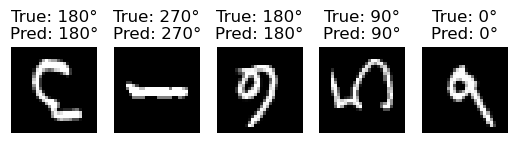

In [5]:
import matplotlib.pyplot as plt

predictions = model.predict(x_test_rot)

num_examples = 5
indices = np.random.choice(len(x_test_rot), num_examples, replace=False)

for i, idx in enumerate(indices):
    img = x_test_rot[idx].squeeze()
    true_label = y_test_rot[idx]
    pred_label = np.argmax(predictions[idx])

    plt.subplot(1, num_examples, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {angles[true_label]}°\nPred: {angles[pred_label]}°")
    plt.axis('off')

plt.show()

## 6.Load Labeled MNIST Data for Fine-Tuning
##### Loads fully labeled MNIST dataset for downstream digit classification task.
##### Preprocesses images and selects smaller subsets for quick fine-tuning.

In [6]:
(x_train_labeled, y_train_labeled), (x_test_labeled,
                                     y_test_labeled) = tf.keras.datasets.mnist.load_data()

x_train_labeled = x_train_labeled.astype('float32') / 255.
x_test_labeled = x_test_labeled.astype('float32') / 255.
x_train_labeled = np.expand_dims(x_train_labeled, -1)
x_test_labeled = np.expand_dims(x_test_labeled, -1)

x_train_fine = x_train_labeled[:1000]
y_train_fine = y_train_labeled[:1000]
x_test_fine = x_test_labeled[:200]
y_test_fine = y_test_labeled[:200]

## 7.Modify and Fine-Tune Model on Labeled Digital Data


##### Freezes convolutional layers to keep learned features unchanged.
##### Replaces output layer to predict 10 digit classes instead of rotations.
##### Compiles and trains the model on labeled data to adapt it for digit recognition.

In [7]:
for layer in model.layers[:-2]:
    layer.trainable = False

model.pop()
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_fine, y_train_fine, epochs=5, batch_size=64,
          validation_data=(x_test_fine, y_test_fine))

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3620 - loss: 2.0117 - val_accuracy: 0.6600 - val_loss: 1.1567
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8020 - loss: 0.7863 - val_accuracy: 0.8250 - val_loss: 0.6362
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8840 - loss: 0.4886 - val_accuracy: 0.8550 - val_loss: 0.4841
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9040 - loss: 0.3823 - val_accuracy: 0.8700 - val_loss: 0.4099
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9230 - loss: 0.3285 - val_accuracy: 0.9000 - val_loss: 0.3459


## 8.Visualize Fine-Tuned Predictions

##### Predicts digit classes on labeled test images after fine-tuning.
##### Randomly selects 5 test images to display.
##### Shows images with ground truth and predicted digit labels for visual performance check.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


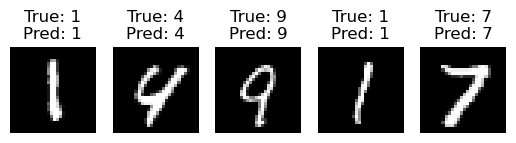

In [8]:
predictions = model.predict(x_test_fine)

indices = np.random.choice(len(x_test_fine), 5, replace=False)

for i, idx in enumerate(indices):
    img = x_test_fine[idx].squeeze()
    true_label = y_test_fine[idx]
    pred_label = np.argmax(predictions[idx])

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.show()